## Part 2: Stiff ODEs and Implicit Methods
#### Group: Sarah Rincon (EID: sr56495), Juan Arellano (EID: jma6353), Juan Cisneros (EID: jc222256)

#### Section 1: Introduction & System Selection
In this project, we solve a stiff ordinary differential equation (ODE) using numerical methods. Stiff ODEs appear in systems where some processes happen very quickly while others change slowly. In these cases, standard explicit methods like Forward Euler can become unstable unless extremely small step sizes are used. For this project, we selected Option B, a simple first-order chemical decay approaching equilibrium. The governing equation describes how the concentration of a chemical substance changes over time as it reacts and approaches equilibrium. The variable C(t) represents the concentration of the chemical species at a given time. This changes as the reaction progresses. The paramater k is the reaction rate constant, which determines how quickly the system responds. Since k in this case is large, this signifies that the reaction happens extremely fast, which creates stiffness in the system. C(eq)(t) represents the equilibrium concentration. The governing ODE describes the rate of change of concentration. 
This type of behavior is common in real-world systems such as combustion, chemical kinetics, and atmospheric reactions, where fast processes interact with slower external conditions.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parameters
lam = 1e4   # stiffness parameter
y0 = 0
t0 = 0
tf = 10

# Equilibrium function
def y_eq(t):
    return 1 + 0.1*np.sin(0.1*t)

# ODE
def f(t, y):
    return -lam*y + lam*y_eq(t)

# derivative wrt y
def dfdy(t, y):
    return -lam

In [2]:
def forward_euler(f, y0, t0, tf, h):
    t_vals = np.arange(t0, tf + h, h)
    y_vals = np.zeros(len(t_vals))
    y_vals[0] = y0

    for i in range(len(t_vals)-1):
        y_vals[i+1] = y_vals[i] + h*f(t_vals[i], y_vals[i])

    return t_vals, y_vals

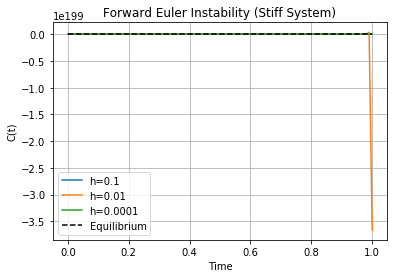

In [3]:
h_values = [0.1, 0.01, 0.0001]

plt.figure()

for h in h_values:
    t, y = forward_euler(f, y0, t0, 1, h)
    plt.plot(t, y, label=f"h={h}")

t_ref = np.linspace(0,1,500)
plt.plot(t_ref, y_eq(t_ref), 'k--', label="Equilibrium")

plt.title("Forward Euler Instability (Stiff System)")
plt.xlabel("Time")
plt.ylabel("C(t)")
plt.legend()
plt.grid()
plt.show()

#### Section 2: Demonstration of Stiffness

To demonstrate stiffness, we attempted to solve the system using the Forward Euler, an explicit method, which uses the current value of the solution to estimate the next value. Since the chemical reaction model has a large reaction rate constant, Forward Euler requires a very small step size to remain stable. For this system, the stability requirement for Forward Euler is approximately: h < 2/λ. Given that λ = 10^4, h must be less than 0.0002. This means the step size must be smaller than 0.0002 seconds for Forward Euler to remain stable. When testing h=0.1 and 0.01, the solution became unstable, instead growing rapidly. When step size was reduced to h = 0.0001 did the solution become stable. To estimate the stiffness ratio, we compared the fast reaction time scale to the slow equilibrium time scale, which gaves us a stiffness ratio of 100,000. This shows that the system contains both very fast and very slow behavior, which demonstrates stiffness. 
Therefore, since it requires such a small step size, Forward Euler is not an efficient method for this problem. An implicit method would be better since it would remain stable for larger step sizes.  

#### Section 3: Mathematical Setup

To solve the stiff chemical reaction model more effectively, we used the Backward Euler, an implicit method.
The Backward Euler method is: 
Cn+1​=Cn​+hf(tn+1​,Cn+1​)
For this problem, f(t,C)=−104C+104(1+0.1sin(0.1t))
Substituting this into Backward Euler gives: Cn+1​=Cn​+h[−104Cn+1​+104(1+0.1sin(0.1tn+1​))]
To solve for Cn+1, define a residual function: 
g(Cn+1) = Cn+1 - Cn - h[-10^4Cn+1 + 10^4(1 + 0.1sin(0.1tn+1))]
The goal is to find the value of Cn+1 that makes this residual equal to zero. Newton-Raphson requires the derivative of the residual. Since the equation is linear, the derivative is : 
g'(Cn+1) = 1 + 10^4 h. The update formula is:
C(new) = C(guess) - (g(C(guess)))/(g'(C(guess))). Since the derivative is constant, the method converges quickly at each time step. 

#### Section 4: Implementation

In [4]:
def newton_step(y_n, t_next, h, tol=1e-8, max_iter=20):
    # initial guess (explicit Euler)
    y_guess = y_n + h*f(t_next, y_n)

    for i in range(max_iter):
        # residual
        g = y_guess - y_n - h*f(t_next, y_guess)

        # derivative
        g_prime = 1 - h*dfdy(t_next, y_guess)

        y_new = y_guess - g/g_prime

        if abs(y_new - y_guess) < tol:
            return y_new, i+1

        y_guess = y_new

    return y_guess, max_iter

In [12]:
def backward_euler(f, dfdy, y0, t0, tf, h):
    t_vals = np.arange(t0, tf + h, h)
    y_vals = np.zeros(len(t_vals))
    iterations = np.zeros(len(t_vals)-1)

    y_vals[0] = y0

    for i in range(len(t_vals)-1):
        t_next = t_vals[i+1]

        y_vals[i+1], iterations[i] = newton_step(
            y_vals[i], t_next, h
        )

    return t_vals, y_vals, iterations


#### Section 5: Results & Analysis

Since Forward Euler became unstable for large step sizes, we applied Backward Euler to the same stiff problem. To test Backward Euler, we used larger step sizes of h=0.1, h = 0.05, and h = 0.01.

The results show how Backward Euler remains stable for these larger step sizes. As we can observe in the plots below, the solution follows the equilbrium concentration in a smooth manner. This is a noticeable difference from Forward Euler, which required a smaller step size to remain stable. It can also be observed that the Newton-Raphson iterations were also tracked at each time step, and that the number of iterations was low (at around 2), indicating that the implicit equation was more efficient. This is also due to the fact that the system is linear in concentration, causing a quicker convergence. 

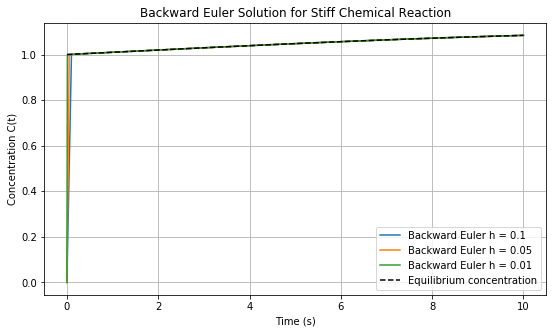

In [14]:
# Step sizes for Backward Euler
h_values_backward = [0.1, 0.05, 0.01]

plt.figure(figsize=(9, 5))

for h in h_values_backward:
    t, y, iters = backward_euler(f, dfdy, y0, t0, tf, h)
    plt.plot(t, y, label=f"Backward Euler h = {h}")

# Reference equilibrium curve
t_ref = np.linspace(t0, tf, 1000)
plt.plot(t_ref, y_eq(t_ref), 'k--', label="Equilibrium concentration")

plt.title("Backward Euler Solution for Stiff Chemical Reaction")
plt.xlabel("Time (s)")
plt.ylabel("Concentration C(t)")
plt.legend()
plt.grid(True)
plt.show()

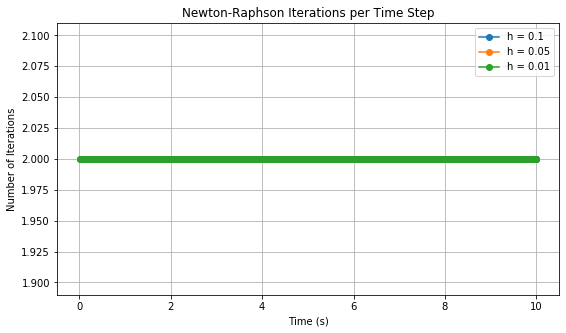

In [18]:
plt.figure(figsize=(9,5))

for h in [0.1, 0.05, 0.01]:
    t, y, iters = backward_euler(f, dfdy, y0, t0, tf, h)
    plt.plot(t[1:], iters, marker='o', label=f"h = {h}")

plt.title("Newton-Raphson Iterations per Time Step")
plt.xlabel("Time (s)")
plt.ylabel("Number of Iterations")
plt.legend()
plt.grid(True)
plt.show()

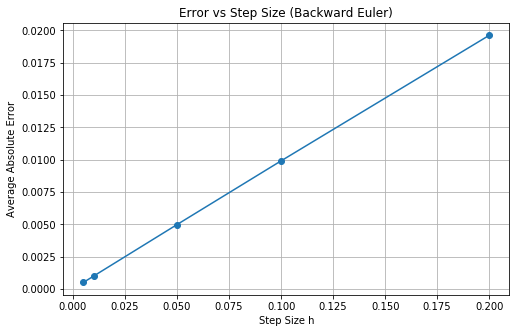

In [17]:
# Step sizes to test
h_values_error = [0.2, 0.1, 0.05, 0.01, 0.005]

errors = []

for h in h_values_error:
    t, y, _ = backward_euler(f, dfdy, y0, t0, tf, h)

    # Reference solution (equilibrium)
    y_true = y_eq(t)

    # Compute average absolute error
    error = np.mean(np.abs(y - y_true))

    errors.append(error)

# Plot error vs step size
plt.figure(figsize=(8,5))
plt.plot(h_values_error, errors, marker='o')

plt.title("Error vs Step Size (Backward Euler)")
plt.xlabel("Step Size h")
plt.ylabel("Average Absolute Error")
plt.grid(True)
plt.show()

#### Section 6: Performance Analysis 
When comparing error vs step size, we find that error increases as step size increases. This demonstrates the tradeoff between accuracy and efficiency, suggesting that smaller step sizes improve accuracy but increase computational cost, while larger step sizes are more efficient but less accurate. 
For Forward Euler, we required a step size smaller than 0.0002 to remain stable, which from a time of 0 to 10 seconds, would require about 50,000 steps, which is a large computational cost for a simple problem. 
Backward Euler can use larger step sizes, while remaining stable, and the cost is much smaller because Newton-Raphson converges quickly.
For stiff systems like this reaction model, we would recommend implicit methods such as Backward Euler, since it provides stable solutions with larger step sizes and since it has lower computational cost. 

In [19]:
h_values = [0.1, 0.05, 0.01]

data = []

# Backward Euler performance
for h in h_values:
    t, y, iters = backward_euler(f, dfdy, y0, t0, tf, h)

    data.append({
        "Method": "Backward Euler",
        "Step Size h": h,
        "Total Steps": len(t)-1,
        "Avg Newton Iterations": round(np.mean(iters),2),
        "Total Function Calls": int(np.sum(iters))
    })

# Forward Euler stability limit
h_stable = 2 / lam
steps_needed = int((tf - t0) / h_stable)

data.append({
    "Method": "Forward Euler",
    "Step Size h": h_stable,
    "Total Steps": steps_needed,
    "Avg Newton Iterations": "N/A",
    "Total Function Calls": steps_needed
})

df = pd.DataFrame(data)
df

,Method,Step Size h,Total Steps,Avg Newton Iterations,Total Function Calls
0,Backward Euler,0.1000,100,2,200
1,Backward Euler,0.0500,200,2,400
2,Backward Euler,0.0100,1000,2,2000
3,Forward Euler,0.0002,50000,N/A,50000


#### Section 7: Conclusions 

This project demonstrated how stiff ODEs create challenges for standard numerical methods. The chemical reaction model we used contained very fast and very slow behavior, which made it difficult to use explicit methods like Forward Euler. 
This shows that Forward Euler is unstable unless an extremely small step size is used, which makes it inefficient and impractical for stiff systems, since it requires a very large number of steps to produce a stable solution. 
In contrast, the Backward Euler method performed a lot better. It remained stable even when using much larger step sizes. The Newton-Raphson method used within Backward Euler converged quickly at each time step, requiring very few iterations. 
From this project, it is clear that explicit methods like Forward Euler is best suited for non-stiff problems where stability is not a major concern. Implicit methods, on the other hand, are best suited for stiff systems, since they provide better stability with larger step sizes. 
One of the challenges we faced was understanding how stiffness affects numerical stability. We learned how implicit methods work and why they are encessary for solving real-world engineering problems. This project taught us the importance of selecting the appropriate numerical method based on the characteristics of the system. 

###### Assistance from ChatGPT (OpenAI, 2026) was used to explain code and to develop table for comparison of Backward and Forward Euler.